$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Professor:}$ Cristiano Fernandes   
$ \textbf{Data:}$ 3 de Outubro de 2026

$ \textbf{Tese de Mestrado - 2026.1:}$ Modelagem de vazão de rios utilizando a distribuição de Harvey

In [34]:
import numpy as np
import pandas as pd
import datetime as dt
import harvey_gev as harvey

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import genextreme
import seaborn as sns
# from scipy.constants import EulerGamma

In [19]:
path = r"C:\Users\aless\Documents\Mestrado\PUC\Tese\Dados\14990000_Cotas.csv"
gamma_E = 0.5772156649015329

# Dados

In [3]:
data = pd.read_csv(path, skiprows=15, encoding='latin-1', sep=';') #, decimal=','

data = data[['Data', 'Maxima','Minima','Media']]
data['Data'] = pd.to_datetime(data['Data'], format='%d/%m/%Y')
data = data.set_index('Data').dropna(how='all')

data = data.resample('ME').mean()
data.at['2014-08-31','Media'] = 2546
data.at['2014-08-31','Maxima'] = 2906

series = data[['Maxima']].dropna()

print(data.shape)
data.head(3)

(1347, 3)


,Maxima,Minima,Media
Data,,,
1902-09-30,2219.0,NaN,NaN
1902-10-31,1970.0,1777.0,1818.0
1902-11-30,1776.5,1680.5,1716.5


In [5]:
# metadados
pd.set_option('display.max_colwidth', None)
pd.DataFrame(index=['Metadados'], data={
    'Fonte':'''Base de dados de vazão do Rio Amazonas da Agência Nacional de Águas (ANA)''', 
    'Unidade':'centímetros (cm)',
    'Período da série': '{} a {}'.format(series.index.min().strftime('%d/%m/%Y'), series.index.max().strftime('%d/%m/%Y')),
    'Observações': '{} meses'.format(series.shape[0])
}).T

,Metadados
Fonte,Base de dados de vazão do Rio Amazonas da Agência Nacional de Águas (ANA)
Unidade,centímetros (cm)
Período da série,30/09/1902 a 30/11/2014
Observações,1347 meses


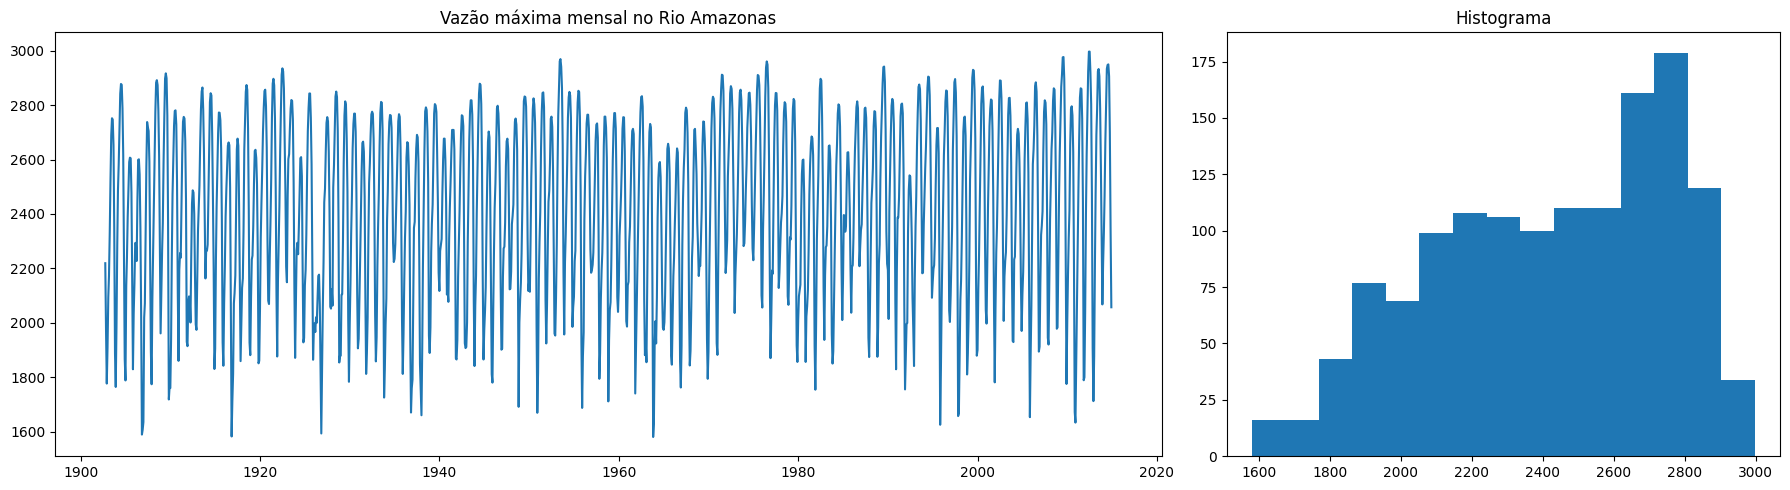

In [96]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={'width_ratios': [2, 1]})

ax[0].plot(series)
ax[0].set_title('Vazão máxima mensal no Rio Amazonas')

ax[1].hist(series, bins=15)
ax[1].set_title('Histograma')

plt.tight_layout()
plt.show()

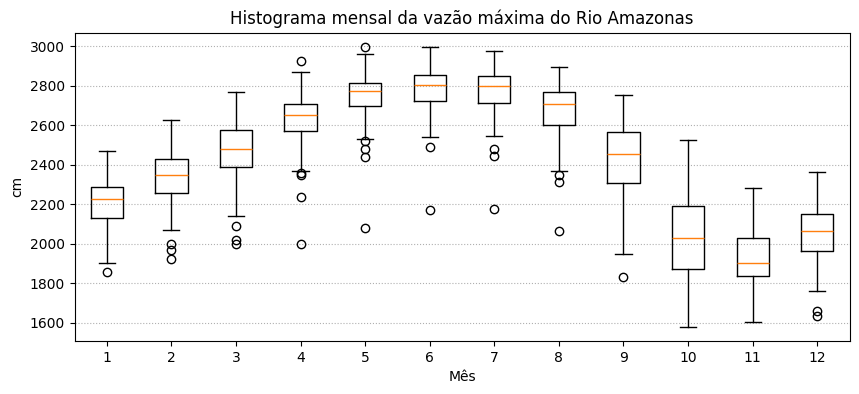

In [5]:
fig, ax = plt.subplots(figsize=(10,4))
plot_data = (series
    .pivot_table(columns=series.index.month, index=series.index.year, values='Maxima')
    .dropna()
)
ax.boxplot(plot_data)
ax.set_ylabel('cm')
ax.set_xlabel('Mês')
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma mensal da vazão máxima do Rio Amazonas')
plt.show()

# Modelagem

\begin{align}
y_t &= \mu_{t|t-1} + \gamma_t+\varphi\varepsilon_t, \qquad \text{com} \quad
\varepsilon_t \sim
\operatorname{GEV}(0,1,\xi) \quad \text{e} \quad
\varphi > 0 \\
\mu_{t+1|t} &= \mu(1-\phi) +\phi\mu_{t|t-1} +\kappa s_t \\
\gamma_t &=
\sum_{j=1}^{6}
\left(
\alpha_j
\cos\left(\frac{2\pi jt}{12}\right)
+
\beta_j
\sin\left(\frac{2\pi jt}{12}\right)
\right)
\end{align}


In [4]:
mu_init, alpha_init, beta_init = harvey.initial_seasonal_coefficients(series)
mu_init, alpha_init, beta_init

(np.float64(2422.0992299436375),
 array([141.6074219 ,  88.1687309 ,  33.90710598,   1.65950603,
         -5.82702788,  -3.59487759]),
 array([-380.24121675,  -38.77080865,   34.64451314,   12.84810774,
           4.03713041]))

In [5]:
t = np.arange(1, len(series) + 1)

gamma_init = harvey.seasonal_component(t, alpha_init, beta_init)
residuos_init = series.to_numpy(dtype=float) - mu_init - gamma_init
varphi_init = np.std(residuos_init)

print("mu inicial:", mu_init)
print("varphi inicial:", varphi_init)

mu inicial: 2422.0992299436375
varphi inicial: 445.3564742701594


In [ ]:
init_params = [
    2422,     # mu
    445,     # varphi
    0.5,   # phi
    0.3,    # kappa
    0.1,    # xi
    *alpha_init,
    *beta_init
]
result = harvey.fit(series, init_params)

In [12]:
params = result.params_original
mu_hat = params[0]
varphi_hat = params[1]
phi_hat = params[2]
kappa_hat = params[3]
xi_hat = params[4]
alpha_hat = params[5:11]
beta_hat = params[11:16]

In [10]:
print("Convergiu:", result.success)
print("Mensagem:", result.message)

print("\nEstimativas:")
print(f"mu: {result.params_original[0]:.3f}")
print(f"varphi: {result.params_original[1]:.3f}")
print(f"phi: {result.params_original[2]:.3f}")
print(f"kappa: {result.params_original[3]:.3f}")
print(f"xi: {result.params_original[4]}")

print("\nLog-likelihood =", -result.fun)

Convergiu: True
Mensagem: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH

Estimativas:
mu: 2293.011
varphi: 459.146
phi: 0.098
kappa: 0.044
xi: 1e-08

Log-likelihood = -13569488.015415248


In [8]:
result

         message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
         success: True
          status: 0
             fun: 13569488.015415248
               x: [ 2.293e+03  4.591e+02 ...  1.039e+01  4.504e+00]
             nit: 17
             jac: [ 2.364e+02  1.132e+03 ...  2.515e+01  2.682e+01]
            nfev: 527
            njev: 31
        hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>
 params_original: [ 2.293e+03  4.591e+02 ...  1.039e+01  4.504e+00]

## Avaliação

In [20]:
mu_filtered, gamma_t, x, s = harvey.filter(
    series, mu_hat, varphi_hat, phi_hat, kappa_hat, xi_hat, alpha_hat, beta_hat
)
eta_t = mu_filtered + gamma_t
mean_cond = mu_filtered + gamma_t + varphi_hat * gamma_E

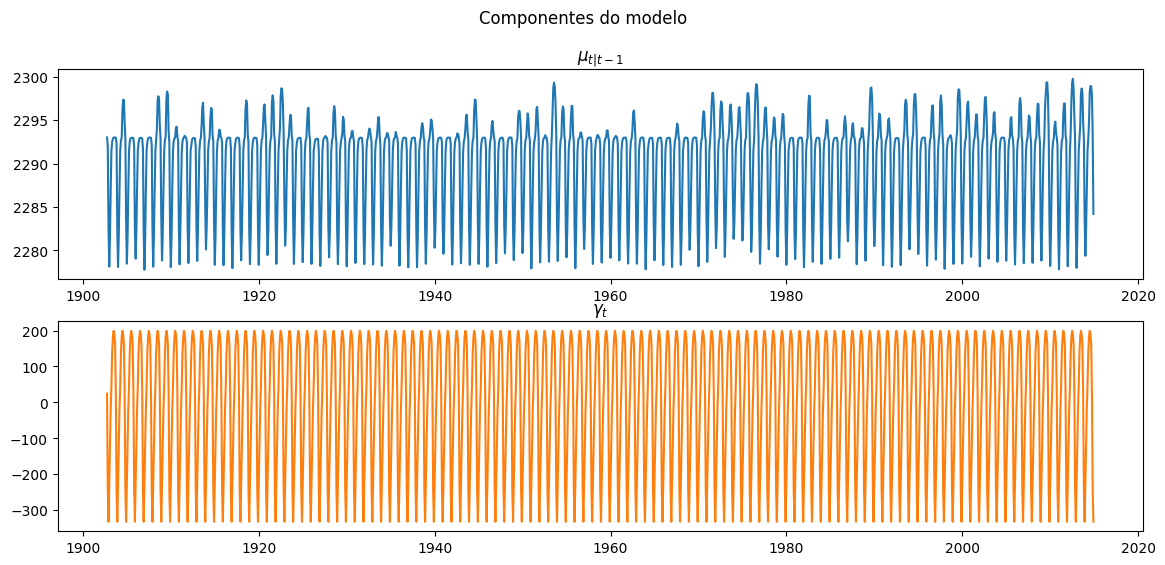

In [30]:
fig, ax = plt.subplots(2, 1, figsize=(14, 6))

ax[0].plot(series.index, mu_filtered, label=r"$\mu_{t|t-1}$")
ax[0].set_title(r"$\mu_{t|t-1}$")

ax[1].plot(series.index, gamma_t, label=r"$\gamma_t$", color='C1')
ax[1].set_title(r"$\gamma_t$")

fig.suptitle("Componentes do modelo")
# plt.legend()
plt.show()

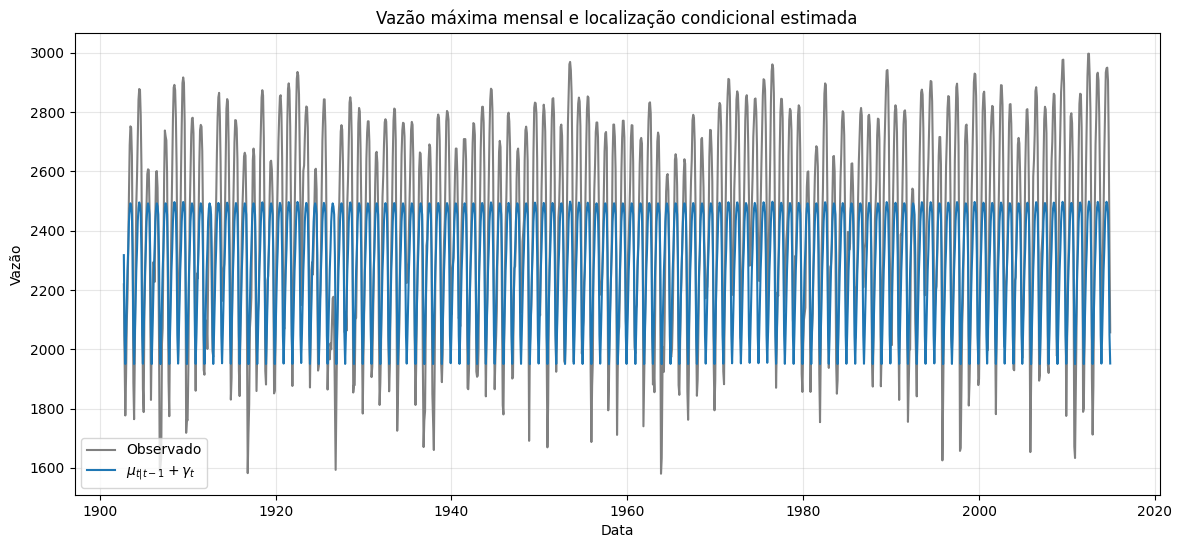

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(series.index, series, label="Observado", color='gray')
plt.plot(series.index, eta_t, label=r"$\mu_{t|t-1} + \gamma_t$")
# plt.plot(series.index, mean_cond, label=r"$E[y_t|\mathcal{F}_{t-1}]$")

plt.xlabel("Data")
plt.ylabel("Vazão")
plt.title("Vazão máxima mensal e localização condicional estimada")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

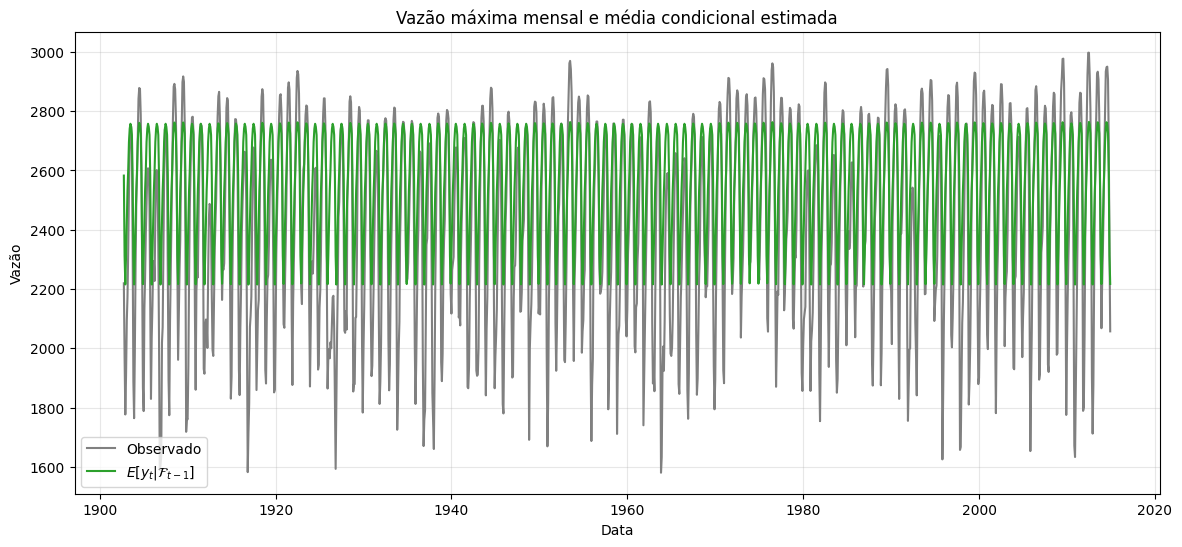

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(series.index, series, label="Observado", color='gray')
# plt.plot(series.index, eta_t, label=r"$\mu_{t|t-1} + \gamma_t$")
plt.plot(series.index, mean_cond, label=r"$E[y_t|\mathcal{F}_{t-1}]$", color='C2')

plt.xlabel("Data")
plt.ylabel("Vazão")
plt.title("Vazão máxima mensal e média condicional estimada")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [43]:
c = harvey._find_c(xi_hat)
d = harvey._find_d(xi_hat)
c, d

(-5.551236534987233e-09, np.float64(18.420682440559865))

In [54]:
harvey.composite_score(d, xi_hat, 0, 1)

array(0.99999999)

In [49]:
series.index[x<c]

DatetimeIndex(['1902-09-30', '1902-10-31', '1902-11-30', '1902-12-31',
               '1903-01-31', '1903-02-28', '1903-03-31', '1903-10-31',
               '1903-11-30', '1903-12-31',
               ...
               '2010-10-31', '2010-11-30', '2010-12-31', '2011-01-31',
               '2011-10-31', '2011-11-30', '2011-12-31', '2012-10-31',
               '2012-11-30', '2012-12-31'],
              dtype='datetime64[ns]', name='Data', length=314, freq=None)

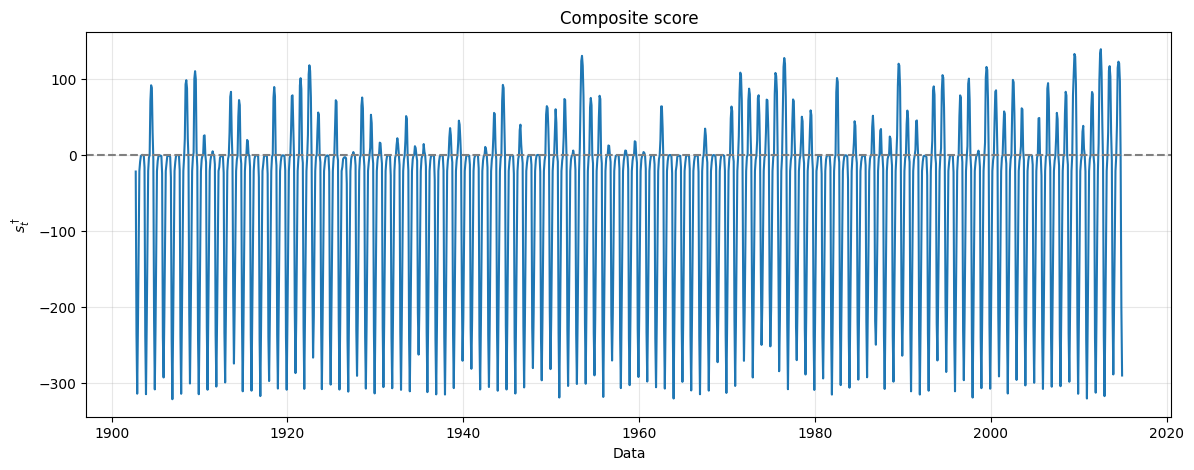

In [41]:
plt.figure(figsize=(14, 5))

plt.plot(series.index, s)
plt.axhline(0, linestyle="--", color='gray')

plt.xlabel("Data")
plt.ylabel(r"$s_t^\dagger$")
plt.title("Composite score")
plt.grid(alpha=0.3)

plt.show()

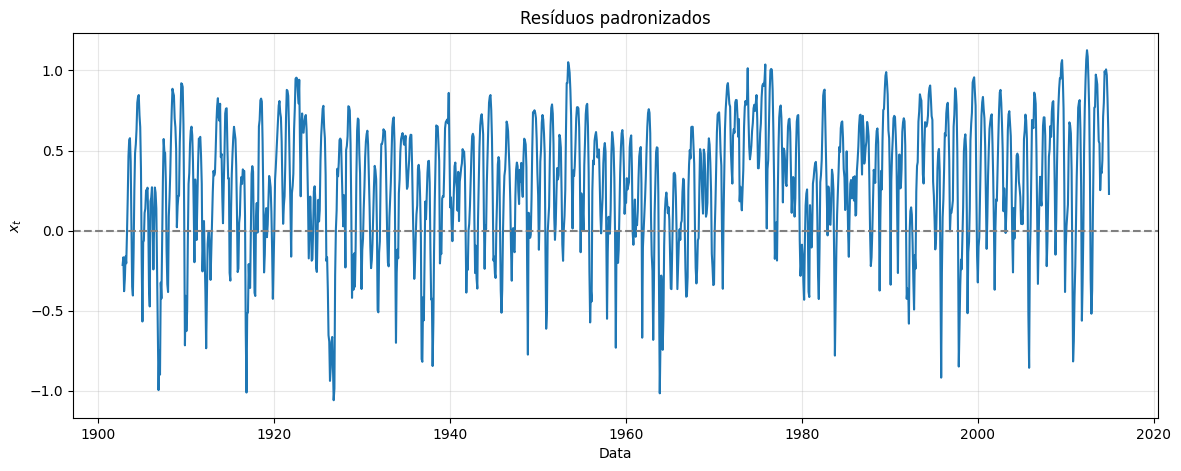

In [32]:
plt.figure(figsize=(14, 5))

plt.plot(series.index, x)
plt.axhline(0, linestyle="--", color='gray')

plt.xlabel("Data")
plt.ylabel(r"$x_t$")
plt.title("Resíduos padronizados")
plt.grid(alpha=0.3)

plt.show()

In [39]:
# x_grid = np.linspace(np.min(x), np.percentile(x, 99.5), 500)
# pdf = genextreme.pdf(x_grid, c=-xi_hat, loc=0, scale=1)

# plt.figure(figsize=(8, 4))
# plt.hist(x, bins=30, density=True, alpha=0.6, label=r"Simulado $\varepsilon_t$")
# plt.plot(x_grid, pdf, label="GEV teórica")
# plt.xlabel(r"$\varepsilon_t$")
# plt.ylabel("Densidade")
# plt.legend()
# plt.tight_layout()
# plt.show()

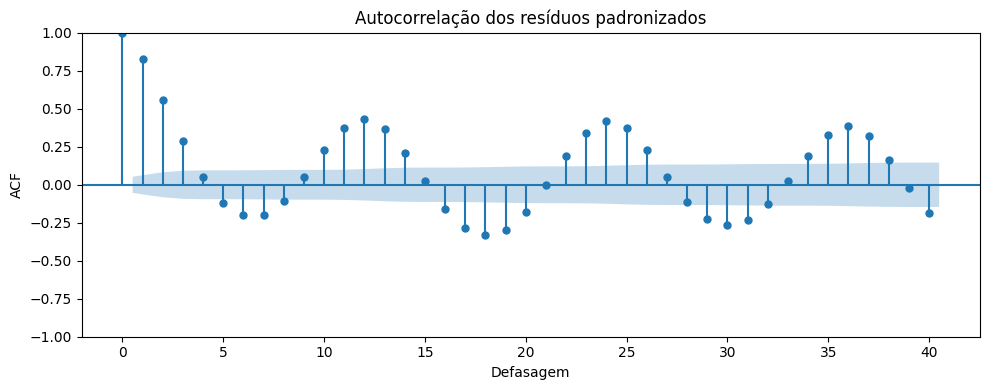

In [36]:
plt.figure(figsize=(10, 4))
plot_acf(x, lags=40, ax=plt.gca())
plt.title("Autocorrelação dos resíduos padronizados")
plt.xlabel("Defasagem")
plt.ylabel("ACF")
plt.tight_layout()
plt.show()

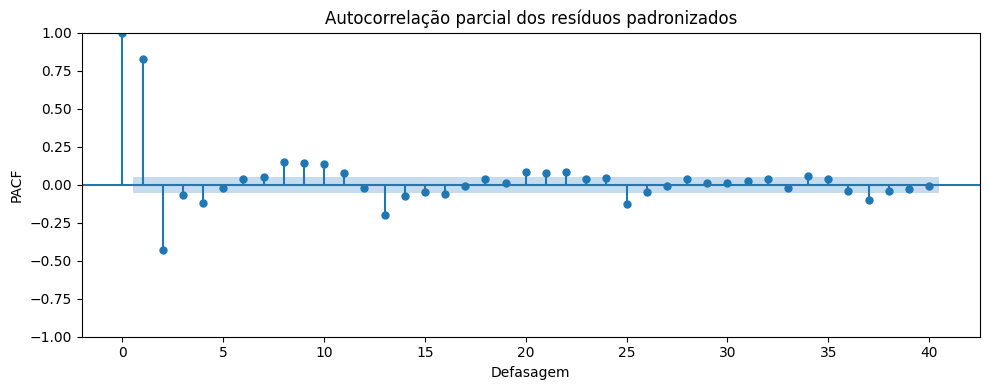

In [38]:
plt.figure(figsize=(10, 4))
plot_pacf(x, lags=40, ax=plt.gca())
plt.title("Autocorrelação parcial dos resíduos padronizados")
plt.xlabel("Defasagem")
plt.ylabel("PACF")
plt.tight_layout()
plt.show()